# Coordinate System Debug Notebook
Step-by-step visualization of coordinate transformations for highlighting

In [1]:
import fitz
import sys
import toml
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
from IPython.display import display

sys.path.insert(0, '.')
import utils_ade as ade

# Load secrets
secrets = toml.load('.streamlit/secrets.toml')
google_cloud_config = {
    'project_number': secrets['google_cloud']['project_number'],
    'location': secrets['google_cloud']['location'],
    'processor_id': secrets['google_cloud']['processor_id'],
    'service_account_info': dict(secrets['gcp_service_account'])
}
landingai_key = secrets['LANDINGAI_API_KEY']

# Load PDF
pdf_path = 'subset_gold/selected_pages_no_annotations.pdf'
pdf_bytes = open(pdf_path, 'rb').read()
doc = fitz.open(pdf_path)
page = doc[0]  # First page

print(f'PDF loaded: {len(doc)} pages')
print(f'Page 1 rotation: {page.rotation}°')
print(f'MediaBox: {page.mediabox.width:.0f} x {page.mediabox.height:.0f}')
print(f'Display rect: {page.rect.width:.0f} x {page.rect.height:.0f}')

PDF loaded: 5 pages
Page 1 rotation: 270°
MediaBox: 1728 x 2592
Display rect: 2592 x 1728


## Step 1: Render the page image (as displayed)

Image size: 3456 x 2304 pixels
PDF display size: 2592 x 1728 points
Scale factor: 1.3333


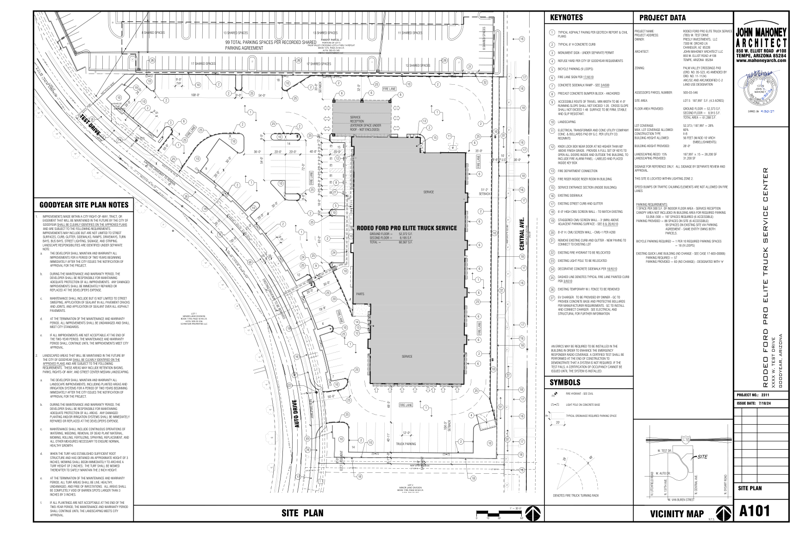

In [2]:
# Render at 96 DPI (same as app)
DISPLAY_DPI = 96
pix = page.get_pixmap(dpi=DISPLAY_DPI)
img_bytes = pix.tobytes('png')
img = Image.open(BytesIO(img_bytes))

print(f'Image size: {img.width} x {img.height} pixels')
print(f'PDF display size: {page.rect.width:.0f} x {page.rect.height:.0f} points')
print(f'Scale factor: {img.width / page.rect.width:.4f}')

# Show scaled down for notebook
img_small = img.copy()
img_small.thumbnail((800, 600))
display(img_small)

## Step 2: Get PDF native text with rotation transform

In [3]:
# Get words from PDF
native_words = page.get_text('words')
print(f'Total words: {len(native_words)}')

# Show first few words in MediaBox coords
print('\nFirst 5 words (MediaBox coords):')
for w in native_words[:5]:
    print(f'  "{w[4]}" at ({w[0]:.1f}, {w[1]:.1f})')

Total words: 1674

First 5 words (MediaBox coords):
  "LOT" at (707.5, 619.8)
  "1" at (707.5, 633.6)
  "MINOR" at (699.2, 592.5)
  "LAND" at (699.2, 616.8)
  "DIVISION" at (699.2, 636.2)


In [4]:
# Transform function for rotation
rotation = page.rotation
mediabox_w = page.mediabox.width
mediabox_h = page.mediabox.height

def transform_for_rotation(x0, y0, x1, y1):
    """Transform MediaBox coords to display coords based on page rotation"""
    if rotation == 0:
        return x0, y0, x1, y1
    elif rotation == 90:
        return mediabox_h - y1, x0, mediabox_h - y0, x1
    elif rotation == 180:
        return mediabox_w - x1, mediabox_h - y1, mediabox_w - x0, mediabox_h - y0
    elif rotation == 270:
        return y0, mediabox_w - x1, y1, mediabox_w - x0
    return x0, y0, x1, y1

# Transform all words
transformed_words = []
for w in native_words:
    nx0, ny0, nx1, ny1 = transform_for_rotation(w[0], w[1], w[2], w[3])
    transformed_words.append({
        'text': w[4],
        'x0': nx0, 'y0': ny0, 'x1': nx1, 'y1': ny1
    })

print(f'Transformed {len(transformed_words)} words')
print('\nFirst 5 words (display coords):')
for w in transformed_words[:5]:
    pct_x = w['x0'] / page.rect.width * 100
    pct_y = w['y0'] / page.rect.height * 100
    print(f'  "{w["text"]}" at ({w["x0"]:.1f}, {w["y0"]:.1f}) = {pct_x:.0f}% x {pct_y:.0f}%')

Transformed 1674 words

First 5 words (display coords):
  "LOT" at (619.8, 1013.6) = 24% x 59%
  "1" at (633.6, 1013.6) = 24% x 59%
  "MINOR" at (592.5, 1021.9) = 23% x 59%
  "LAND" at (616.8, 1021.9) = 24% x 59%
  "DIVISION" at (636.2, 1021.9) = 25% x 59%


## Step 3: Visualize PDF text positions


"SITE" - 8 matches:
  "SITE" at (913, 1651) -> pixel (1217, 2201)
  "SITE" at (2392, 1576) -> pixel (3189, 2101)
  "SITE" at (2259, 1475) -> pixel (3012, 1966)

"PLAN" - 10 matches:
  "PLAN" at (983, 1651) -> pixel (1311, 2201)
  "PLAN" at (2429, 1576) -> pixel (3239, 2101)
  "PLANS" at (1808, 114) -> pixel (2411, 152)

"KEYNOTES" - 1 matches:
  "KEYNOTES" at (1782, 47) -> pixel (2376, 62)

"LOT" - 8 matches:
  "LOT" at (620, 1014) -> pixel (826, 1352)
  "LOT" at (1085, 136) -> pixel (1447, 181)
  "LOTS" at (1075, 144) -> pixel (1434, 192)


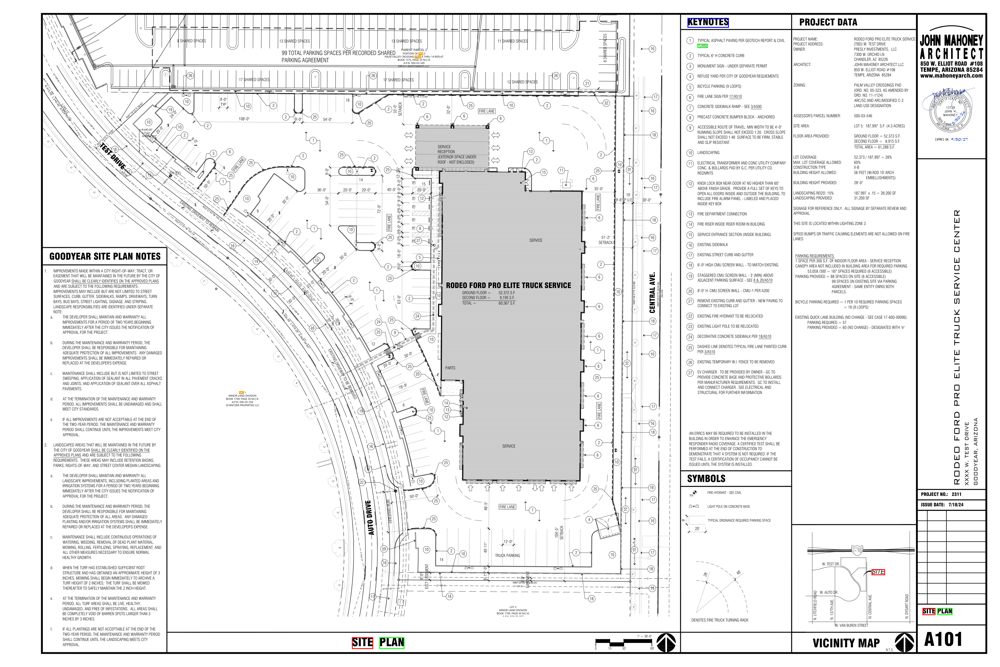


Red=SITE, Green=PLAN, Blue=KEYNOTES, Orange=LOT


In [5]:
# Draw boxes around specific words to verify alignment
img_viz = img.copy()
draw = ImageDraw.Draw(img_viz, 'RGBA')

scale_x = img.width / page.rect.width
scale_y = img.height / page.rect.height

# Find and highlight specific words
test_words = ['SITE', 'PLAN', 'KEYNOTES', 'LOT']
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 165, 0)]

for test_word, color in zip(test_words, colors):
    matches = [w for w in transformed_words if test_word in w['text'].upper()]
    print(f'\n"{test_word}" - {len(matches)} matches:')
    for m in matches[:3]:
        box = [
            m['x0'] * scale_x,
            m['y0'] * scale_y,
            m['x1'] * scale_x,
            m['y1'] * scale_y
        ]
        draw.rectangle(box, outline=color + (255,), width=3)
        print(f'  "{m["text"]}" at ({m["x0"]:.0f}, {m["y0"]:.0f}) -> pixel ({box[0]:.0f}, {box[1]:.0f})')

# Show
img_viz_small = img_viz.copy()
img_viz_small.thumbnail((1000, 750))
display(img_viz_small)
print('\nRed=SITE, Green=PLAN, Blue=KEYNOTES, Orange=LOT')

## Step 4: Get OCR text and verify coordinates

In [6]:
# Run OCR
pdf_width, pdf_height = page.rect.width, page.rect.height
single_page_pdf = ade.create_single_page_pdf(pdf_bytes, 0)
ocr_lines = ade.run_google_ocr_blocks(single_page_pdf, google_cloud_config, pdf_width, pdf_height)

print(f'OCR found {len(ocr_lines)} paragraphs')
print('\nSample OCR lines:')
for line in ocr_lines[:5]:
    pct_x = line['x0'] / pdf_width * 100
    pct_y = line['y0'] / pdf_height * 100
    print(f'  "{line["text"][:30]}" at ({line["x0"]:.1f}, {line["y0"]:.1f}) = {pct_x:.0f}% x {pct_y:.0f}%')

[DEBUG] Starting Google OCR...
[DEBUG] Rendering page image with Zoom: 1.54...
[DEBUG] Image dimensions: 4000 x 2667 pixels
[DEBUG] PDF dimensions: 2592.0 x 1728.0 points


E0000 00:00:1764640575.929978 1040189 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


[DEBUG] Image rendered. Size: 1.49 MB. Sending to Google API...
[DEBUG] Google API returned successfully. Text length: 9404
[DEBUG] Scale factors: x=0.6480, y=0.6479
[DEBUG] OCR extraction complete. Found 479 paragraphs.
OCR found 479 paragraphs

Sample OCR lines:
  "-12"-DIP-W-" at (134.1, 184.7) = 5% x 11%
  "L:166.12'" at (155.5, 261.8) = 6% x 15%
  "R:475,00 L:246.40' 4:029°43'18" at (114.0, 215.8) = 4% x 12%
  "-12"-DIP-W-" at (220.3, 305.8) = 9% x 18%
  "8-PVC-S-" at (222.9, 369.3) = 9% x 21%



"CMU" - 3 OCR matches:
  "18) 6'-0" HIGH CMU SCREEN WALL - TO MATC" at (1783, 681)
  "STAGGERED CMU SCREEN WALL - 3' (MIN) ABO" at (1807, 708)
  "(20) 8'-0" H. CMU SCREEN WALL - CMU-1 PE" at (1779, 746)

"FENCE" - 1 OCR matches:
  "26) EXISTING TEMPORARY W.I. FENCE TO BE " at (1784, 932)

"KEYNOTES" - 1 OCR matches:
  "KEYNOTES" at (1783, 46)


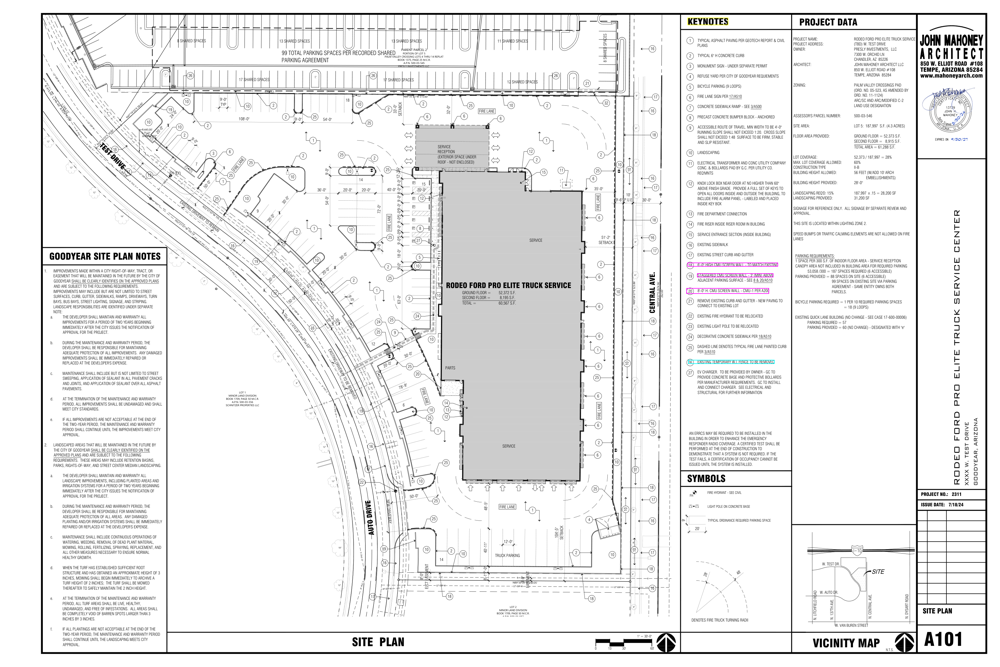


Magenta=CMU, Cyan=FENCE, Yellow=KEYNOTES


In [7]:
# Visualize OCR positions
img_ocr = img.copy()
draw_ocr = ImageDraw.Draw(img_ocr, 'RGBA')

# Find OCR lines containing specific text
test_texts = ['CMU', 'FENCE', 'KEYNOTES']
colors_ocr = [(255, 0, 255), (0, 255, 255), (255, 255, 0)]

for test_text, color in zip(test_texts, colors_ocr):
    matches = [l for l in ocr_lines if test_text in l['text'].upper()]
    print(f'\n"{test_text}" - {len(matches)} OCR matches:')
    for m in matches[:3]:
        box = [
            m['x0'] * scale_x,
            m['y0'] * scale_y,
            m['x1'] * scale_x,
            m['y1'] * scale_y
        ]
        draw_ocr.rectangle(box, outline=color + (255,), width=2)
        print(f'  "{m["text"][:40]}" at ({m["x0"]:.0f}, {m["y0"]:.0f})')

# Show
img_ocr_small = img_ocr.copy()
img_ocr_small.thumbnail((1000, 750))
display(img_ocr_small)
print('\nMagenta=CMU, Cyan=FENCE, Yellow=KEYNOTES')

## Step 5: Get ADE chunks and visualize

In [8]:
# Parse with ADE
ade_result = ade.ade_parse_document(pdf_bytes, landingai_key)
chunks = ade.align_ade_chunks_to_page(ade_result, 0, pdf_width, pdf_height)
legend_chunks, figure_chunks = ade.segment_chunks(chunks)

print(f'Legend chunks: {len(legend_chunks)}')
print(f'Figure chunks: {len(figure_chunks)}')

for i, chunk in enumerate(figure_chunks):
    pct_w = (chunk['x1'] - chunk['x0']) / pdf_width * 100
    pct_h = (chunk['y1'] - chunk['y0']) / pdf_height * 100
    print(f'\nFigure {i}:')
    print(f'  Type: {chunk["type"]}')
    print(f'  Bbox: ({chunk["x0"]:.0f}, {chunk["y0"]:.0f}) - ({chunk["x1"]:.0f}, {chunk["y1"]:.0f})')
    print(f'  Size: {pct_w:.0f}% x {pct_h:.0f}% of page')

[DEBUG] Starting ADE Parsing for document (4716966 bytes)...
[DEBUG] ADE API Request - Attempt 1
[DEBUG] ADE Success! Found 76 chunks across 5 pages.
[DEBUG] Segmented: 7 Legend-like chunks, 2 Figure-like chunks.
Legend chunks: 7
Figure chunks: 2

Figure 0:
  Type: figure
  Bbox: (96, 24) - (1761, 1704)
  Size: 64% x 97% of page

Figure 1:
  Type: figure
  Bbox: (2052, 1357) - (2377, 1700)
  Size: 13% x 20% of page


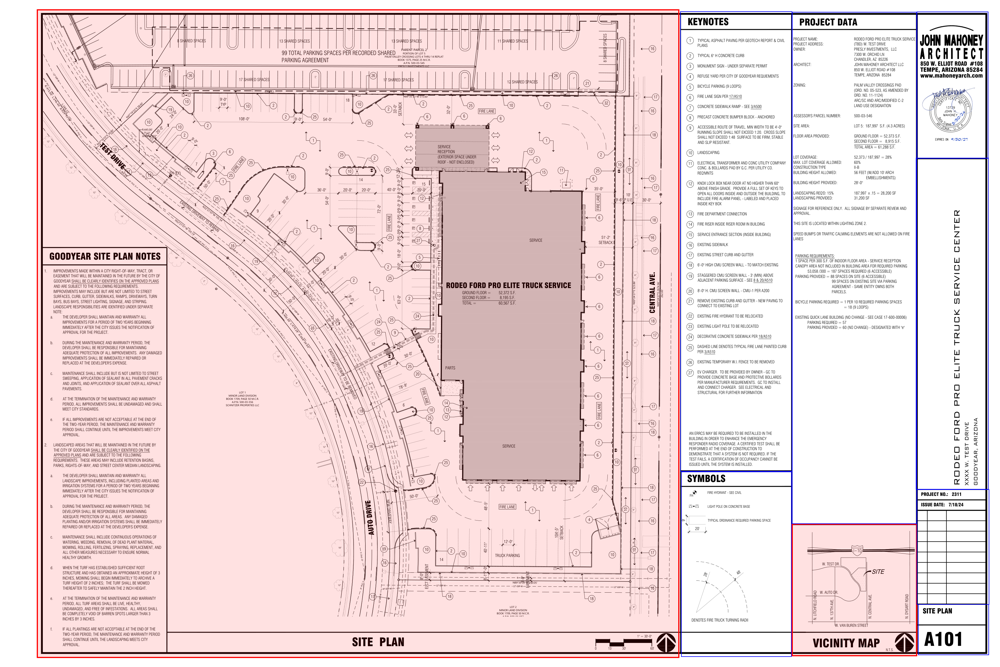

Red (filled) = Figure chunks, Blue = Legend chunks


In [9]:
# Visualize ADE chunks
img_ade = img.copy()
draw_ade = ImageDraw.Draw(img_ade, 'RGBA')

# Draw figure chunks in red
for chunk in figure_chunks:
    box = [
        chunk['x0'] * scale_x,
        chunk['y0'] * scale_y,
        chunk['x1'] * scale_x,
        chunk['y1'] * scale_y
    ]
    draw_ade.rectangle(box, outline=(255, 0, 0, 255), width=4)
    draw_ade.rectangle(box, fill=(255, 0, 0, 30))

# Draw legend chunks in blue
for chunk in legend_chunks:
    box = [
        chunk['x0'] * scale_x,
        chunk['y0'] * scale_y,
        chunk['x1'] * scale_x,
        chunk['y1'] * scale_y
    ]
    draw_ade.rectangle(box, outline=(0, 0, 255, 255), width=2)

# Show
img_ade_small = img_ade.copy()
img_ade_small.thumbnail((1000, 750))
display(img_ade_small)
print('Red (filled) = Figure chunks, Blue = Legend chunks')

## Step 6: Find indicator instances in figure chunks

In [10]:
# Get PDF native lines (with rotation transform)
pdf_lines = ade.get_native_pdf_lines(page)
print(f'PDF lines: {len(pdf_lines)}')

# Extract definitions from legend chunks
from langchain_openai import ChatOpenAI
openai_key = secrets['OPENAI_API_KEY']
llm = ChatOpenAI(model='gpt-4o-mini', api_key=openai_key, temperature=0)

FENCE_KEYWORDS = ['fence', 'fencing', 'chain link', 'wrought iron', 'gate', 'railing', 
                  'barrier', 'post', 'picket', 'wire mesh', 'security fence', 'privacy fence',
                  'ornamental', 'bollard', 'guardrail', 'handrail', 'balustrade', 
                  'screen wall', 'cmu', 'masonry', 'wall', 'rail']

definitions = ade.extract_legend_entries(
    legend_chunks=legend_chunks,
    pdf_lines=pdf_lines,
    ocr_lines=ocr_lines,
    fence_keywords=FENCE_KEYWORDS,
    llm=llm
)

print(f'\nDefinitions found: {len(definitions)}')
for d in definitions:
    print(f'  Indicator: "{d["indicator"]}" -> "{d.get("keyword", "")[:40]}"')

[DEBUG] PDF Native extraction: Found 653 lines.
PDF lines: 653
[DEBUG] Extracting Legend Entries and Matching BBoxes...
[DEBUG] Asking LLM to extract items from text length 3820...
[DEBUG] LLM found 5 candidates.
[DEBUG] Asking LLM to extract items from text length 680...
[DEBUG] LLM found 0 candidates.
[DEBUG] Asking LLM to extract items from text length 2364...
[DEBUG] LLM found 0 candidates.
[DEBUG] Asking LLM to extract items from text length 320...
[DEBUG] LLM found 0 candidates.
[DEBUG] Asking LLM to extract items from text length 129...
[DEBUG] LLM found 0 candidates.
[DEBUG] Asking LLM to extract items from text length 798...
[DEBUG] LLM found 0 candidates.
[DEBUG] Asking LLM to extract items from text length 71...
[DEBUG] LLM found 0 candidates.
[DEBUG] Finished Legend Extraction. Total mapped items: 10

Definitions found: 10
  Indicator: "18" -> "6'-0" HIGH CMU SCREEN WALL - TO MATCH EX"
  Indicator: "18" -> "18"
  Indicator: "19" -> "STAGGERED CMU SCREEN WALL - 3' (MIN) ABO"

In [11]:
# Find instances in figure chunks
instances = ade.find_instances_in_figures(definitions, figure_chunks, transformed_words)

print(f'Instances found: {len(instances)}')
for inst in instances[:10]:
    pct_x = inst['x0'] / pdf_width * 100
    pct_y = inst['y0'] / pdf_height * 100
    print(f'  "{inst["indicator"]}" at ({inst["x0"]:.0f}, {inst["y0"]:.0f}) = {pct_x:.0f}% x {pct_y:.0f}%')

[DEBUG] Finding Instances in Figure Chunks...
[DEBUG] Figure chunks count: 2
[DEBUG]   Figure 0: type=figure bbox=(95.8, 24.5) - (1760.7, 1704.5)
[DEBUG]   Figure 1: type=figure bbox=(2052.4, 1357.0) - (2377.5, 1700.0)
[DEBUG] Looking for indicators: {'26', '18', '19', '20', '11'}
[DEBUG] Tokens inside figure chunks: 1009 (out of 1674 total)
[DEBUG] ✓ Found instance '18' at (896.0, 255.2) token='18'
[DEBUG] ✓ Found instance '18' at (1690.3, 345.2) token='18'
[DEBUG] ✓ Found instance '18' at (1690.3, 565.7) token='18'
[DEBUG] ✓ Found instance '18' at (1687.0, 827.6) token='18'
[DEBUG] ✓ Found instance '18' at (1687.0, 1115.7) token='18'
[DEBUG] ✓ Found instance '18' at (1684.3, 1259.1) token='18'
[DEBUG] ✓ Found instance '18' at (1682.6, 1469.7) token='18'
[DEBUG] ✓ Found instance '18' at (1528.9, 1546.5) token='18'
[DEBUG] ✓ Found instance '18' at (1160.2, 1540.7) token='18'
[DEBUG] ✓ Found instance '19' at (931.0, 1060.8) token='19'
[DEBUG] ✓ Found instance '19' at (990.3, 1417.7) tok

## Step 7: Final visualization with all highlights

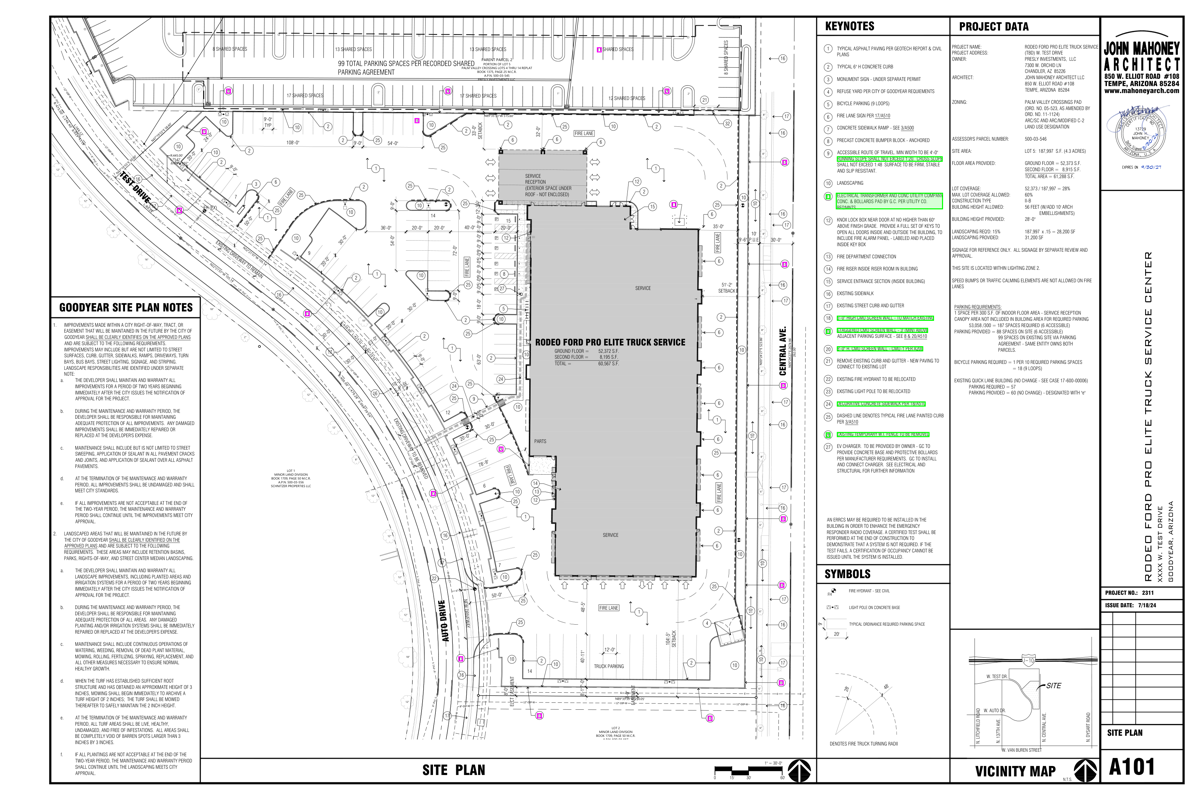


Green = Definitions (10), Purple = Instances (20)


In [12]:
# Create final highlighted image
img_final = img.copy()
draw_final = ImageDraw.Draw(img_final, 'RGBA')

# Draw definitions in green
for d in definitions:
    box = [
        d['x0'] * scale_x,
        d['y0'] * scale_y,
        d['x1'] * scale_x,
        d['y1'] * scale_y
    ]
    draw_final.rectangle(box, outline=(0, 255, 0, 255), width=3)
    draw_final.rectangle(box, fill=(0, 255, 0, 40))

# Draw instances in purple
for inst in instances:
    box = [
        inst['x0'] * scale_x,
        inst['y0'] * scale_y,
        inst['x1'] * scale_x,
        inst['y1'] * scale_y
    ]
    draw_final.rectangle(box, outline=(255, 0, 255, 255), width=3)

# Show
img_final_small = img_final.copy()
img_final_small.thumbnail((1200, 900))
display(img_final_small)
print(f'\nGreen = Definitions ({len(definitions)}), Purple = Instances ({len(instances)})')

In [13]:
# Save full resolution image for inspection
img_final.save('debug_highlighted_page1.png')
print('Saved full resolution image to debug_highlighted_page1.png')

Saved full resolution image to debug_highlighted_page1.png


In [14]:
# Cleanup
doc.close()